In [1]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
# Definimos la ruta donde estan los archivos
path = r'../data/raw/'

In [ ]:
# Listamos todos los archivos que empiecen por "data" y terminen en ".parquet"
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [ ]:
# Leemos cada archivo y colocamos en una lista de DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [5]:
# Concatenar en un solo DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

## Análisis descriptivo

In [6]:
# Mostrar las primeras filas del dataset
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
0,2020-09-08 00:00:00-04:00,93.113965,93.462744,91.806050,92.174202,1225600,0.0,0.0,A,96.138635,...,3.0,0.054972,1,3.0,0.036578,1,3.0,0.070141,1,3.0
1,2020-09-09 00:00:00-04:00,93.104280,95.400403,92.871764,94.877235,954400,0.0,0.0,A,95.520526,...,2.0,0.020321,1,3.0,-0.010416,0,1.0,0.062670,1,3.0
2,2020-09-10 00:00:00-04:00,95.797603,96.979573,95.177554,95.497269,1933200,0.0,0.0,A,94.580765,...,2.0,0.010449,1,2.0,-0.022623,0,0.0,0.058616,1,3.0
3,2020-09-11 00:00:00-04:00,95.632924,96.514560,94.964430,95.526352,1368600,0.0,0.0,A,94.379250,...,2.0,0.007911,1,2.0,-0.009229,0,1.0,0.074550,1,3.0
4,2020-09-14 00:00:00-04:00,96.621112,97.105525,95.884801,96.320770,1207700,0.0,0.0,A,94.879166,...,2.0,-0.012975,0,1.0,0.000905,1,2.0,0.062363,1,3.0


In [ ]:
f'Total de filas {df.shape[0]} y total de Columnas {df.shape[1]}'

'Total de filas 620095 y total de Columnas 73'

In [8]:
df.columns


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Ticker', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50',
       'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI',
       'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position',
       'Volatility', 'Price_Change', 'Price_Change_5d', 'High_Low_Ratio',
       'Open_Close_Ratio', 'Volume_SMA', 'Volume_Ratio', 'Close_lag_1',
       'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10',
       'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5',
       'Volume_lag_10', 'Price_Change_lag_1', 'Price_Change_lag_2',
       'Price_Change_lag_3', 'Price_Change_lag_5', 'Price_Change_lag_10',
       'RSI_lag_1', 'RSI_lag_2', 'RSI_lag_3', 'RSI_lag_5', 'RSI_lag_10',
       'MACD_lag_1', 'MACD_lag_2', 'MACD_lag_3', 'MACD_lag_5', 'MACD_lag_10',
       'Volatility_lag_1', 'Volatility_lag_2', 'Volatility_lag_3',
       'Volatility_lag_5', 'Volatility_lag_10', 'Future_Return_1d',

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620095 entries, 0 to 620094
Data columns (total 73 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 620095 non-null  object 
 1   Open                 620095 non-null  float64
 2   High                 620095 non-null  float64
 3   Low                  620095 non-null  float64
 4   Close                620095 non-null  float64
 5   Volume               620095 non-null  int64  
 6   Dividends            620095 non-null  float64
 7   Stock Splits         620095 non-null  float64
 8   Ticker               620095 non-null  object 
 9   SMA_5                620095 non-null  float64
 10  SMA_10               620095 non-null  float64
 11  SMA_20               620095 non-null  float64
 12  SMA_50               620095 non-null  float64
 13  EMA_12               620095 non-null  float64
 14  EMA_26               620095 non-null  float64
 15  MACD             

In [10]:
df.dtypes

Date                    object
Open                   float64
High                   float64
Low                    float64
Close                  float64
                        ...   
Future_Up_10d            int64
Future_Category_10d    float64
Future_Return_20d      float64
Future_Up_20d            int64
Future_Category_20d    float64
Length: 73, dtype: object

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,620095.0,1.706274e+02,3.487984e+02,2.216000,5.408444e+01,1.007565e+02,1.937515e+02,9.914170e+03
High,620095.0,1.726560e+02,3.529315e+02,2.318000,5.475288e+01,1.020246e+02,1.960136e+02,9.964770e+03
Low,620095.0,1.685721e+02,3.447943e+02,2.195000,5.341888e+01,9.950196e+01,1.914322e+02,9.794000e+03
Close,620095.0,1.706449e+02,3.488749e+02,2.225000,5.408973e+01,1.008029e+02,1.937215e+02,9.924400e+03
Volume,620095.0,6.096960e+06,2.343659e+07,0.000000,1.006000e+06,2.122600e+06,4.888700e+06,1.543911e+09
...,...,...,...,...,...,...,...,...
Future_Up_10d,620095.0,5.446746e-01,4.980006e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Future_Category_10d,620095.0,1.638134e+00,1.270877e+00,0.000000,0.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00
Future_Return_20d,620095.0,1.339101e-02,8.911601e-02,-0.641508,-3.891694e-02,1.078353e-02,6.139018e-02,2.223735e+00
Future_Up_20d,620095.0,5.468420e-01,4.978014e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [12]:
df.duplicated() 

0         False
1         False
2         False
3         False
4         False
          ...  
620090    False
620091    False
620092    False
620093    False
620094    False
Length: 620095, dtype: bool

In [13]:
df.isna().mean().sort_values(ascending=False).head(15)

Date            0.0
Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
Ticker          0.0
SMA_5           0.0
SMA_10          0.0
SMA_20          0.0
SMA_50          0.0
EMA_12          0.0
EMA_26          0.0
dtype: float64

In [14]:
# Convertir date a formato fecha

df['Date'] = pd.to_datetime(df['Date'])


C:\Users\Work\AppData\Local\Temp\ipykernel_11088\2582450478.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [15]:
# Revisar null
nulls = df.isna().mean().sort_values(ascending=False)
nulls[nulls > 0]


Series([], dtype: float64)

In [16]:
# revisar duplicados
df.duplicated().sum()


np.int64(0)

In [17]:
df.duplicated(subset=['Ticker', 'Date']).sum()


np.int64(0)

In [18]:
# Rango de fechas
df['Date'].min(), df['Date'].max()


(Timestamp('2020-07-15 00:00:00-0400', tz='UTC-04:00'),
 Timestamp('2025-06-27 00:00:00-0400', tz='UTC-04:00'))

In [19]:
# mostrar datos en ticker
df['Ticker'].nunique()


503

In [20]:
df.groupby('Ticker').size().describe()


count     503.000000
mean     1232.793241
std        95.270390
min       234.000000
25%      1245.000000
50%      1245.000000
75%      1245.000000
max      1245.000000
dtype: float64

In [21]:
df.describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
Open,620095.0,1.706274e+02,3.487984e+02,2.216000,10.924163,21.633631,1.007565e+02,4.625625e+02,1.024647e+03,9.914170e+03
High,620095.0,1.726560e+02,3.529315e+02,2.318000,11.100152,21.938324,1.020246e+02,4.679113e+02,1.034996e+03,9.964770e+03
Low,620095.0,1.685721e+02,3.447943e+02,2.195000,10.757175,21.320154,9.950196e+01,4.572662e+02,1.013831e+03,9.794000e+03
Close,620095.0,1.706449e+02,3.488749e+02,2.225000,10.924146,21.637885,1.008029e+02,4.628330e+02,1.024541e+03,9.924400e+03
Volume,620095.0,6.096960e+06,2.343659e+07,0.000000,141400.000000,339600.000000,2.122600e+06,1.958504e+07,6.334651e+07,1.543911e+09
...,...,...,...,...,...,...,...,...,...,...
Future_Up_10d,620095.0,5.446746e-01,4.980006e-01,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Future_Category_10d,620095.0,1.638134e+00,1.270877e+00,0.000000,0.000000,0.000000,2.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
Future_Return_20d,620095.0,1.339101e-02,8.911601e-02,-0.641508,-0.199898,-0.120371,1.078353e-02,1.544374e-01,2.665013e-01,2.223735e+00
Future_Up_20d,620095.0,5.468420e-01,4.978014e-01,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
df['Future_Up_1d']

0         1
1         1
2         1
3         1
4         1
         ..
620090    1
620091    1
620092    0
620093    0
620094    0
Name: Future_Up_1d, Length: 620095, dtype: int64

## Graficas

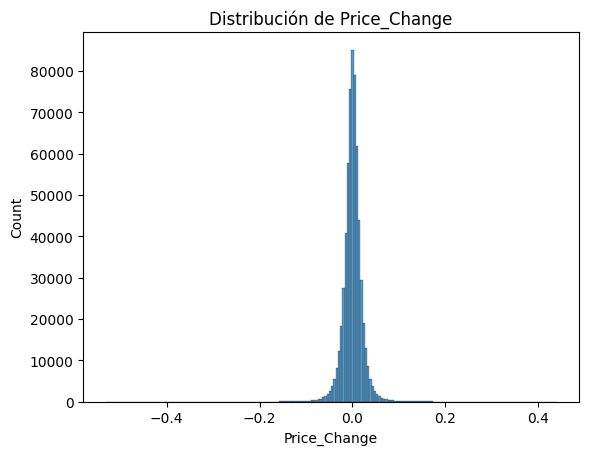

In [ ]:
sns.histplot(df['Price_Change'], bins=200)
plt.title('Distribución de Price_Change')
plt.show()


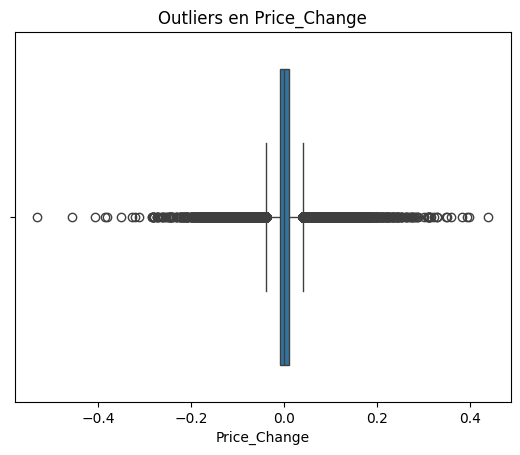

In [ ]:
sns.boxplot(x=df['Price_Change'])
plt.title('Outliers en Price_Change')
plt.show()


In [24]:
df['Price_Change'].value_counts

<bound method IndexOpsMixin.value_counts of 0        -0.017555
1         0.029325
2         0.006535
3         0.000305
4         0.008316
            ...   
620090    0.003069
620091    0.009180
620092    0.004873
620093   -0.008752
620094   -0.003052
Name: Price_Change, Length: 620095, dtype: float64>

## Observaciones
Se observan outliers en los retornos diarios, coherentes con eventos extremos de mercado.

In [ ]:
df_market = (df.groupby('Date').agg(mkt_ret_1d=('Future_Return_1d', 'mean'),
                                    mkt_ret_10d=('Future_Return_10d', 'mean'),
                                    mkt_ret_20d=('Future_Return_20d', 'mean'),
                                    avg_volatility=('Volatility', 'mean'),
                                    avg_rsi=('RSI', 'mean'),
                                    pct_negative_returns=('Price_Change', lambda x: (x < 0).mean()),
                                    cross_sectional_std=('Price_Change', 'std'))
                                .sort_index())


In [26]:
df_market['crisis_20d'] = (df_market['mkt_ret_20d'] < -0.05).astype(int)


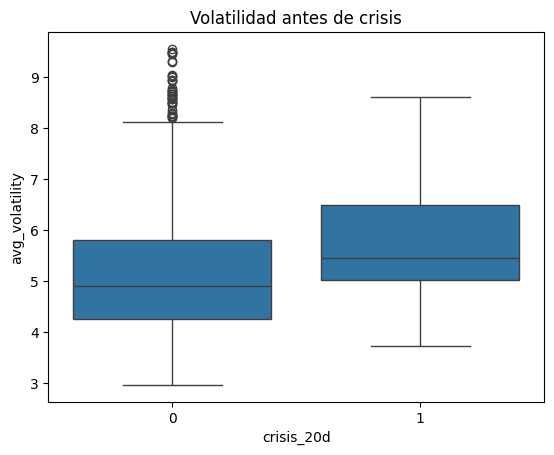

In [ ]:
sns.boxplot(data=df_market, x='crisis_20d', y='avg_volatility')
plt.title('Volatilidad antes de crisis')
plt.show()


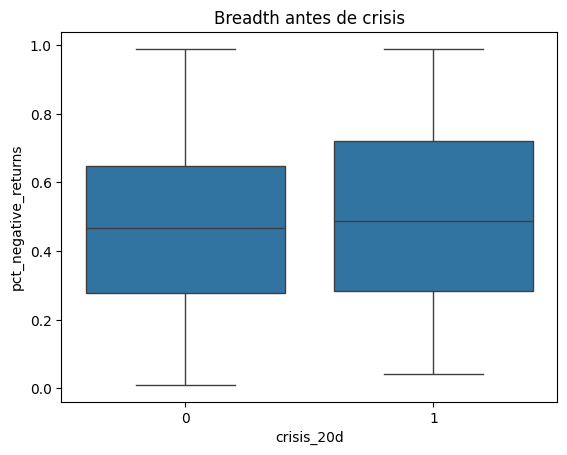

In [ ]:
sns.boxplot(data=df_market, x='crisis_20d', y='pct_negative_returns')
plt.title('Breadth antes de crisis')
plt.show()


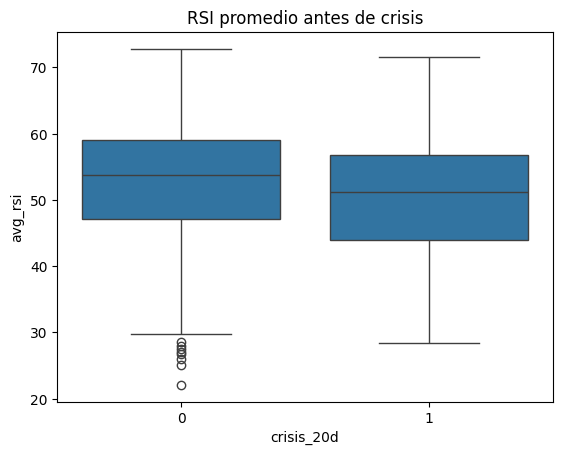

In [ ]:
sns.boxplot(data=df_market, x='crisis_20d', y='avg_rsi')
plt.title('RSI promedio antes de crisis')
plt.show()



In [ ]:
cols_needed = ['Date',
               'Price_Change',
                'RSI',
                'Volatility',
                'Volume_Ratio',
                'Future_Return_10d',
                'Future_Return_20d']

df_risk_raw = df[cols_needed].copy()


In [31]:
df_risk_raw.isna().mean()


Date                 0.0
Price_Change         0.0
RSI                  0.0
Volatility           0.0
Volume_Ratio         0.0
Future_Return_10d    0.0
Future_Return_20d    0.0
dtype: float64

In [32]:
df_risk_raw = df_risk_raw.dropna()


In [ ]:
df_market = 
    (df_risk_raw
    .groupby('Date')
    .agg(
        # Retornos futuros (solo para target)
        mkt_ret_10d=('Future_Return_10d', 'mean'),
        mkt_ret_20d=('Future_Return_20d', 'mean'),

        # Señales de riesgo (features)
        avg_volatility=('Volatility', 'mean'),
        avg_rsi=('RSI', 'mean'),
        pct_negative_returns=('Price_Change', lambda x: (x < 0).mean()),
        cross_sectional_std=('Price_Change', 'std'),
        avg_volume_ratio=('Volume_Ratio', 'mean')
    )
    .sort_index()
)


In [34]:
df_market.head()
df_market.describe()


,mkt_ret_10d,mkt_ret_20d,avg_volatility,avg_rsi,pct_negative_returns,cross_sectional_std,avg_volume_ratio
count,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000
mean,0.006717,0.013421,5.217484,52.520881,0.477035,0.016867,1.013707
std,0.031693,0.043158,1.281756,8.793425,0.237878,0.005063,0.224002
min,-0.126967,-0.118411,2.963211,22.107179,0.010060,0.006416,0.299792
25%,-0.010682,-0.015322,4.291377,46.989586,0.278884,0.013559,0.890884
50%,0.008182,0.016963,4.954296,53.585391,0.469185,0.016226,0.984635
75%,0.027030,0.041511,5.879988,58.859771,0.651303,0.018967,1.088490
max,0.121420,0.169998,9.553840,72.806462,0.989940,0.080966,2.389050


In [35]:
df_market['crisis'] = (df_market['mkt_ret_20d'] < -0.05).astype(int)


In [36]:
df_market['crisis'].value_counts(normalize=True)


crisis
0    0.922088
1    0.077912
Name: proportion, dtype: float64

In [37]:
features = [
    'avg_volatility',
    'avg_rsi',
    'pct_negative_returns',
    'cross_sectional_std',
    'avg_volume_ratio'
]

X = df_market[features]
y = df_market['crisis']


In [38]:
split_1 = int(len(df_market) * 0.7)
split_2 = int(len(df_market) * 0.85)

X_train = X.iloc[:split_1]
y_train = y.iloc[:split_1]

X_val = X.iloc[split_1:split_2]
y_val = y.iloc[split_1:split_2]

X_test = X.iloc[split_2:]
y_test = y.iloc[split_2:]


In [39]:
X_train.index.max(), X_test.index.min()


(Timestamp('2023-12-28 00:00:00-0500', tz='UTC-05:00'),
 Timestamp('2024-09-27 00:00:00-0400', tz='UTC-04:00'))

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)